# Taller 2: operaciones de transformación del histograma

### Sebastián Palma

### David Tobón Molina

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Filtros lineales suavizantes


## 2. Filtros lineales separables

## 3. Filtros no lineales

Los filtros lineales calculan siempre un promedio ponderado de todos los píxeles de un cierto vecindario. Los filtros no lineales permiten, entre otras, hacer una selección dentro de este vecindario y utilizar únicamente un subconjunto de píxeles que presentan propiedades comunes.

### 3.2 Cargue la imagen morpho en escala de grises y visualícela.

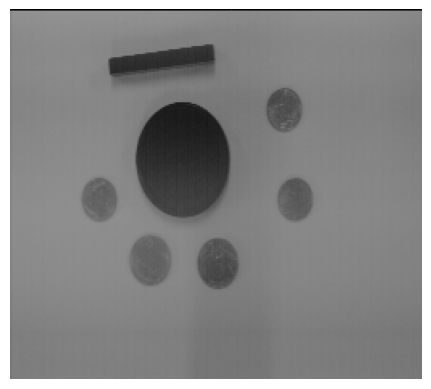

In [14]:
morpho_img = cv2.imread('images/MORPHO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(morpho_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Perturbe (ensucie) la imagen con 25% de ruido “sal y pimienta”. En la imagen ya existen pixeles aberrantes (con intensidades extremas). Esta operación es hecha para amplificar el fenómeno y facilitar la respuesta a la pregunta 9. Nota: El ruido “pimienta y sal” está constituido de picos claros y oscuros (cuyos valores se deben definir en el módulo) con distribución espacial aleatoria. 25 % de pixeles perturbados por este ruido son suficientes para que la imagen morpho.png sea bastante degradada.

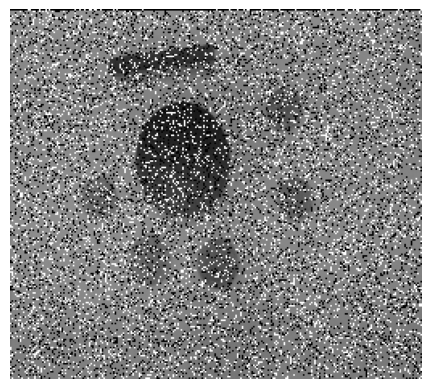

In [15]:
from skimage.util import random_noise

noised_image = random_noise(morpho_img, mode='s&p', amount=0.25)
plt.imshow(noised_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()

### 3.4 Aplique un filtro promedio 3x3 sobre la imagen con ruido. Visualmente, ¿cómo es el resultado y a qué se debe?

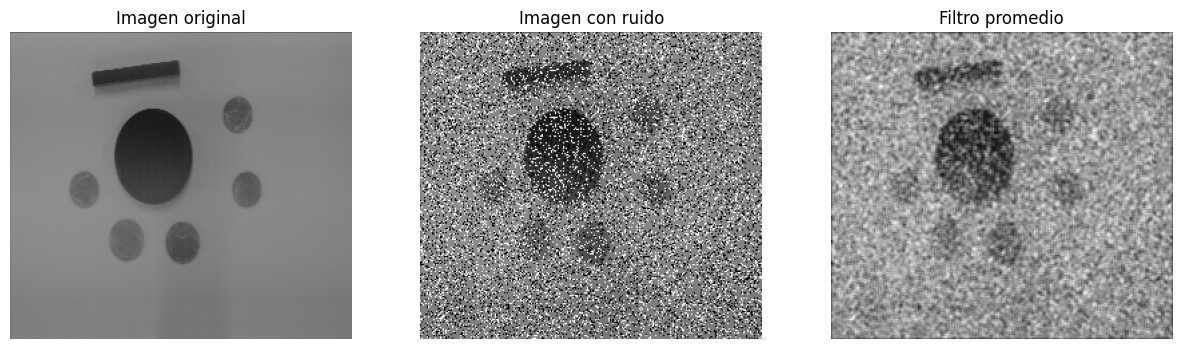

In [ ]:
from scipy.ndimage import convolve

kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]])

avg_filter_result = convolve(noised_image, kernel, mode='constant', cval=0)

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(morpho_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Imagen original')

plt.subplot(1,3,2)
plt.imshow(noised_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Imagen con ruido')

plt.subplot(1,3,3)
plt.imshow(avg_filter_result, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Filtro promedio')

plt.show()


El ruido de la imagen se suaviza pero sigue siendo ruido y no se recuperan los detalles de la imagen original, lo que eran los puntos blancos y negros se vuelven manchas de grises claros y oscuros. Esto se debe a que los filtros promedio toman en cuenta todos los píxeles bajo su ventana. En este caso, se toman en cuenta los 9 píxeles de la imagen que se encuentran en la ventana de 3x3. Al tomar en cuenta todos los píxeles y hacer un promedio, los valores de los píxeles ruido afectan en gran parte al resultado, pues estos hacen que el resultado del promedio aritmético de las intensidades de los píxeles se desplace significativamente. Por ejemplo, un solo píxel de "sal" (255) en una vecindad de píxeles oscuros elevará el promedio de toda la celda, creando una mancha gris clara en lugar de eliminar el punto blanco.

## 4. Ejercicio de síntesis taller 5